In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from collections import Counter 
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report ,confusion_matrix


Original class distribution: Counter({0: 897, 1: 103})


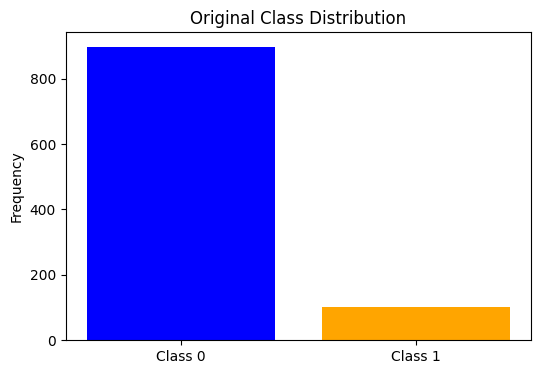

Resampled class distribution: Counter({0: 897, 1: 897})


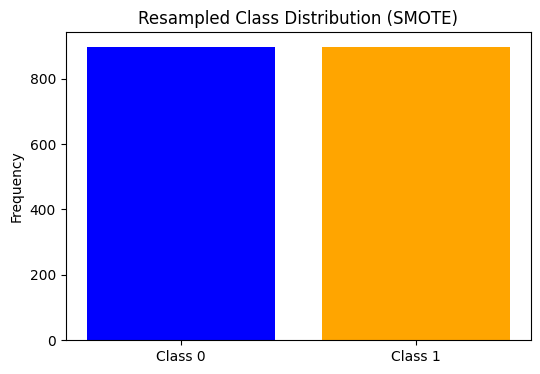

Classification report on resampled data:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       272
           1       0.98      0.95      0.97       267

    accuracy                           0.97       539
   macro avg       0.97      0.97      0.97       539
weighted avg       0.97      0.97      0.97       539



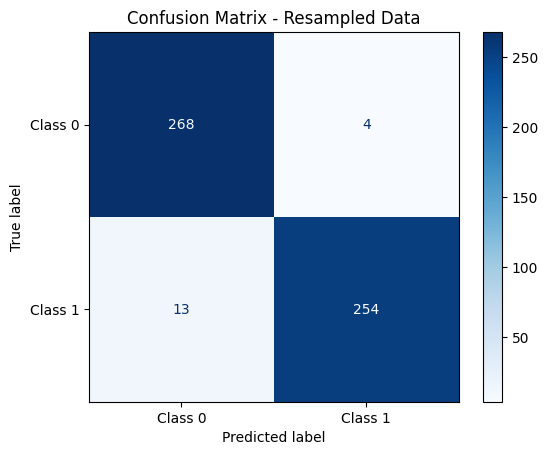

Classification report on imbalanced data:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       262
           1       0.92      0.89      0.91        38

    accuracy                           0.98       300
   macro avg       0.95      0.94      0.95       300
weighted avg       0.98      0.98      0.98       300



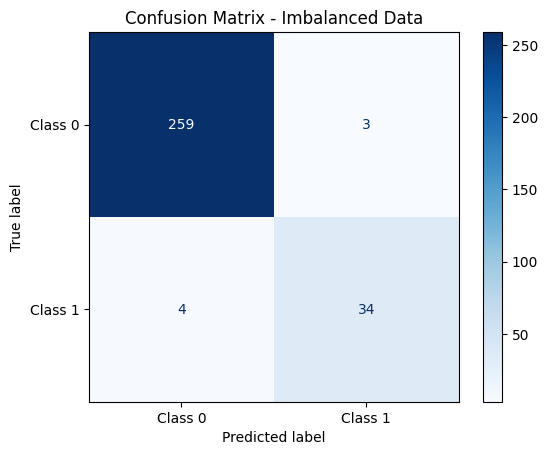

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# Generate imbalanced dataset , Synthetic Minority Over-sampling Technique
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, 
                           class_sep=2, weights=[0.9, 0.1], random_state=42)

# Display class distribution
print("Original class distribution:", Counter(y))

# Plot the class distribution
plt.figure(figsize=(6,4))
plt.bar(['Class 0', 'Class 1'], [Counter(y)[0], Counter(y)[1]], color=['blue', 'orange'])
plt.title('Original Class Distribution')
plt.ylabel('Frequency')
plt.show()

# Apply SMOTE (Synthetic Minority Over-sampling Technique) for oversampling
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Display new class distribution
print("Resampled class distribution:", Counter(y_res))

# Plot the resampled class distribution
plt.figure(figsize=(6,4))
plt.bar(['Class 0', 'Class 1'], [Counter(y_res)[0], Counter(y_res)[1]], color=['blue', 'orange'])
plt.title('Resampled Class Distribution (SMOTE)')
plt.ylabel('Frequency')
plt.show()

# Train and evaluate a Naive Bayes classifier on the resampled data
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

# Using Naive Bayes Classifier
clf = GaussianNB()
clf.fit(X_train, y_train)
y_pred_resampled = clf.predict(X_test)

# Evaluate the model on the resampled dataset
print("Classification report on resampled data:")
print(classification_report(y_test, y_pred_resampled))

# Confusion Matrix for resampled data
cm_resampled = confusion_matrix(y_test, y_pred_resampled)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_resampled, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Resampled Data")
plt.show()

# Now, evaluate the model on the original imbalanced data
X_train_imbalanced, X_test_imbalanced, y_train_imbalanced, y_test_imbalanced = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the Naive Bayes Classifier on imbalanced data
clf.fit(X_train_imbalanced, y_train_imbalanced)
y_pred_imbalanced = clf.predict(X_test_imbalanced)

# Evaluate the model on the original imbalanced dataset
print("Classification report on imbalanced data:")
print(classification_report(y_test_imbalanced, y_pred_imbalanced))

# Confusion Matrix for imbalanced data
cm_imbalanced = confusion_matrix(y_test_imbalanced, y_pred_imbalanced)
disp_imbalanced = ConfusionMatrixDisplay(confusion_matrix=cm_imbalanced, display_labels=['Class 0', 'Class 1'])
disp_imbalanced.plot(cmap='Blues')
plt.title("Confusion Matrix - Imbalanced Data")
plt.show()

# You can compare metrics like precision, recall, and F1-score to see how much improvement SMOTE brings


In [2]:
import seaborn as sns

In [3]:
X,y = make_classification(n_samples=1000,n_features=10,n_classes=2,class_sep=2,weights=[0.9,0.1],random_state=42)
        

MSE on test data: 103.47302683438758


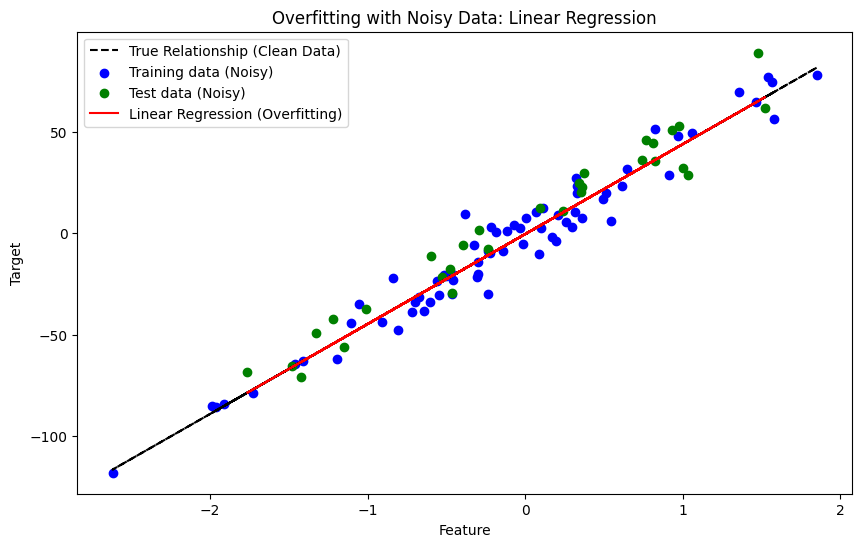

In [10]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generate noisy data (with noise added)
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train a Linear Regression model (no regularization)
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Print the Mean Squared Error (MSE) on the test set
print("MSE on test data:", mean_squared_error(y_test, y_pred))

# Plot the training data, test data, and model predictions
plt.figure(figsize=(10, 6))

# Plot the original clean data line (without noise)
X_clean = X_train  # Using training data as the "clean" data
y_clean = model.predict(X_clean)  # Predicting the clean data's target values
plt.plot(X_clean, y_clean, color='black', linestyle='--', label='True Relationship (Clean Data)')

# Plot the training and test data points
plt.scatter(X_train, y_train, color='blue', label='Training data (Noisy)')
plt.scatter(X_test, y_test, color='green', label='Test data (Noisy)')

# Plot the linear regression line (overfitting)
plt.plot(X_test, y_pred, color='red', label='Linear Regression (Overfitting)')
h
# Labels and title
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Overfitting with Noisy Data: Linear Regression')
plt.legend()

# Show the plot
plt.show()
